Введите радиус щётки в метрах (например 0.3):  0.1


C:\Users\furmi\AppData\Local\Temp\ipykernel_15604\109510586.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab20', len(polygons))


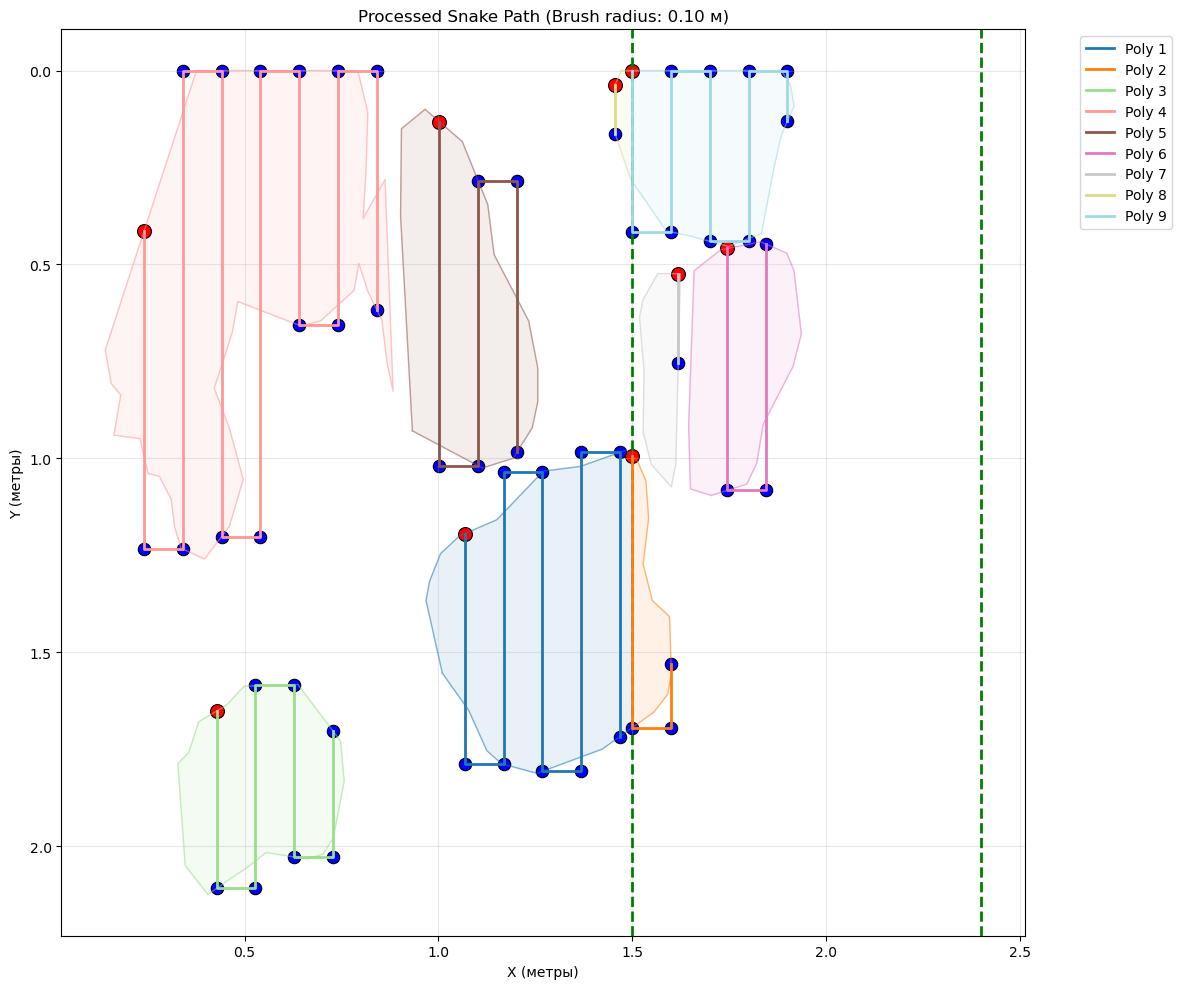

1)Left, 10, 0.100, (1.068;1.194)(1.068;1.789)(1.168;1.789)(1.168;1.036)(1.268;1.036)(1.268;1.807)(1.368;1.807)(1.368;0.985)(1.468;0.985)(1.468;1.717)
2)Middle, 4, 0.100, (1.500;0.995)(1.500;1.695)(1.600;1.695)(1.600;1.530)
3)Left, 8, 0.100, (0.428;1.652)(0.428;2.109)(0.528;2.109)(0.528;1.584)(0.628;1.584)(0.628;2.028)(0.728;2.028)(0.728;1.703)
4)Left, 14, 0.100, (0.241;0.415)(0.241;1.234)(0.341;1.234)(0.341;0.000)(0.441;0.000)(0.441;1.202)(0.541;1.202)(0.541;0.000)(0.641;0.000)(0.641;0.657)(0.741;0.657)(0.741;0.000)(0.841;0.000)(0.841;0.617)
5)Left, 6, 0.100, (1.002;0.132)(1.002;1.019)(1.102;1.019)(1.102;0.284)(1.202;0.284)(1.202;0.985)
6)Middle, 4, 0.100, (1.745;0.459)(1.745;1.083)(1.845;1.083)(1.845;0.448)
7)Middle, 2, 0.100, (1.619;0.524)(1.619;0.753)
8)Left, 2, 0.100, (1.455;0.038)(1.455;0.163)
9)Middle, 10, 0.100, (1.500;0.000)(1.500;0.416)(1.600;0.416)(1.600;0.000)(1.700;0.000)(1.700;0.441)(1.800;0.441)(1.800;0.000)(1.900;0.000)(1.900;0.131)


In [8]:
# ... (предыдущий код остается без изменений до функции plot_results)

def plot_results(polygons, brush_radius, new_points_data):
    fig, ax = plt.subplots(figsize=(14, 10))
    colors = plt.cm.get_cmap('tab20', len(polygons))
    
    # Рисуем только полигоны
    for i, polygon in enumerate(polygons):
        if polygon.geom_type == 'Polygon' and not polygon.is_empty:
            x, y = polygon.exterior.xy
            ax.plot(x, y, color=colors(i), linewidth=1, alpha=0.5)
            ax.fill(x, y, color=colors(i), alpha=0.1)
    
    # Разделительные линии (в метрах)
    ax.axvline(x=0.5*3, color='green', linestyle='--', linewidth=2)
    ax.axvline(x=0.8*3, color='green', linestyle='--', linewidth=2)
    
    # Рисуем только новые маршруты (обработанные координаты)
    for i, (section, poly_idx, points) in enumerate(new_points_data):
        if not points:
            continue
        
        # Генерируем оригинальный путь
        original_path = generate_snake_path(points, brush_radius*3)
        
        # Обрабатываем координаты
        processed_path = process_coordinates(original_path)
        
        # Рисуем линии нового маршрута
        if len(processed_path) > 1:
            x, y = zip(*processed_path)
            ax.plot(x, y, color=colors(i), linestyle='-', linewidth=2, label=f'Poly {poly_idx}')
        
        # Рисуем точки нового маршрута
        for j, (x_p, y_p) in enumerate(processed_path):
            marker = 'o'
            color = 'red' if j == 0 else 'blue'  # Первая точка - красная, остальные - синие
            size = 100 if j == 0 else 80  # Первая точка больше
            ax.scatter(x_p, y_p, color=color, s=size, marker=marker,
                      edgecolors='black', linewidths=0.8)
    
    ax.set_aspect('equal')
    plt.xlabel('X (метры)')
    plt.ylabel('Y (метры)')
    plt.title(f'Processed Snake Path (Brush radius: {brush_radius*3:.2f} м)')
    plt.grid(True, alpha=0.3)
    plt.gca().invert_yaxis()
    
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
    
    # Вывод результатов после графика в одну строку
    for section, poly_idx, points in new_points_data:
        original_path = generate_snake_path(points, brush_radius*3)
        if not original_path:
            continue
            
        processed_path = process_coordinates(original_path)
        if not processed_path:
            continue
            
        # Формируем строку с координатами
        coords_str = "".join(f"({x:.3f};{y:.3f})" for x, y in processed_path)
        
        # Вывод в одну строку в требуемом формате
        print(f"{poly_idx}){section}, {len(processed_path)}, {brush_radius*3:.3f}, {coords_str}")

# Основной код
file_path = '.ipynb_checkpoints/PrujectNN/example_lables/f1_2864_jpg.rf.f6616f4bc31b8622ae0dee004de13bef.txt'
polygons = parse_data(file_path)

brush_radius_input = float(input("Введите радиус щётки в метрах (например 0.3): "))
brush_radius = brush_radius_input / 3  # Конвертируем в единицы графика (1 единица = 3 метра)

split_polygons, new_points_data = process_polygons(polygons, brush_radius)

if split_polygons:
    plot_results(split_polygons, brush_radius, new_points_data)
else:
    print("Нет полигонов для отображения!")

Creating colored polygons plot...


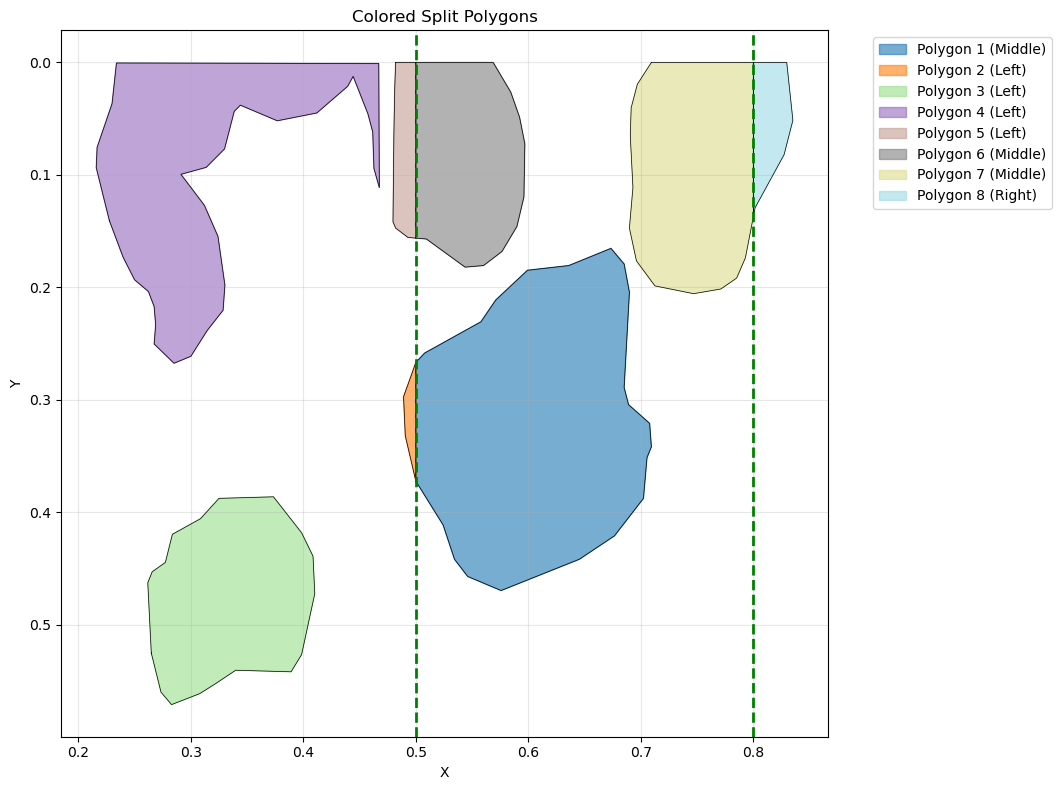

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Polygon, LineString, MultiPolygon
from shapely.ops import split
from matplotlib.colors import ListedColormap

def parse_data(file_path):
    with open(file_path, 'r') as file:
        lines = file.readlines()

    polygons = []
    current_polygon = []

    for line in lines:
        data = line.strip().split(" ")[1:]  # Удаляем первый элемент
        if not data:  # Если строка пустая, пропускаем
            continue
        
        coords = list(map(float, data))
        current_polygon.extend(zip(coords[::2], coords[1::2]))  # Пара (x, y)

        if line.startswith('0'):
            if current_polygon:
                polygons.append(Polygon(current_polygon))
                current_polygon = []

    if current_polygon:
        polygons.append(Polygon(current_polygon))

    return polygons

def create_halses(polygon, spacing):
    minx, miny, maxx, maxy = polygon.bounds
    halses = []
    x = minx
    while x <= maxx:
        line = LineString([(x, miny), (x, maxy)])
        intersection = polygon.intersection(line)
        if intersection.is_empty:
            x += spacing
            continue
        if intersection.geom_type == 'MultiLineString':
            for geom in intersection.geoms:
                halses.append(geom)
        elif intersection.geom_type == 'LineString':
            halses.append(intersection)
        x += spacing
    return halses

def split_polygon_with_lines(polygon):
    split_lines = [
        LineString([(0.5, polygon.bounds[1]), (0.5, polygon.bounds[3])]),
        LineString([(0.8, polygon.bounds[1]), (0.8, polygon.bounds[3])])
    ]
    
    result = [polygon]
    
    for split_line in split_lines:
        temp = []
        for geom in result:
            if geom.geom_type not in ['Polygon', 'MultiPolygon']:
                continue
                
            if geom.intersects(split_line):
                try:
                    parts = split(geom, split_line)
                    if parts.geom_type == 'MultiPolygon':
                        temp.extend(parts.geoms)
                    elif parts.geom_type == 'GeometryCollection':
                        for part in parts.geoms:
                            if part.geom_type == 'Polygon':
                                temp.append(part)
                    else:
                        temp.append(parts)
                except:
                    temp.append(geom)
            else:
                temp.append(geom)
        result = temp
    
    # Фильтруем только непустые полигоны
    return [geom for geom in result if geom.geom_type == 'Polygon' and not geom.is_empty]

def determine_section(polygon):
    minx, _, maxx, _ = polygon.bounds
    if maxx <= 0.5:
        return "Left"
    elif minx >= 0.8:
        return "Right"
    else:
        return "Middle"

def plot_colored_polygons(polygons):
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Создаем цветовую карту
    colors = plt.cm.tab20(np.linspace(0, 1, len(polygons)))
    
    for i, polygon in enumerate(polygons):
        x, y = polygon.exterior.xy
        ax.fill(x, y, color=colors[i], alpha=0.6, label=f'Polygon {i+1} ({determine_section(polygon)})')
        ax.plot(x, y, color='black', linewidth=0.5)
    
    # Разделительные линии
    ax.axvline(x=0.5, color='green', linestyle='--', linewidth=2)
    ax.axvline(x=0.8, color='green', linestyle='--', linewidth=2)
    
    ax.set_aspect('equal')
    plt.title('Colored Split Polygons')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.grid(True, alpha=0.3)
    plt.gca().invert_yaxis()
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Основной код
file_path = '.ipynb_checkpoints/PrujectNN/example_lables/f1_2759_jpg.rf.a158e3f8e17acb7e2c37fb5070ed1431.txt'
polygons = parse_data(file_path)

# Разделяем полигоны
split_polygons = []
for polygon in polygons:
    split_polygons.extend(split_polygon_with_lines(polygon))

# Создаем график с цветными полигонами
if split_polygons:
    print("Creating colored polygons plot...")
    plot_colored_polygons(split_polygons)
else:
    print("No polygons to display!")

Enter brush radius:  0.03
